In [ ]:
import geopandas as gpd
import pathlib
import contextily
import matplotlib.pyplot as plt
import matplotlib_scalebar.scalebar as sb
import pandas as pd
from shapely.geometry import Polygon, Point, LineString
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import osmnx as ox
from matplotlib.lines import Line2D
import tilemapbase
import seaborn as sns
import matplotlib.colors as mcolors

In [2]:
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / 'data'
MAP_DIRECTORY = NOTEBOOK_PATH / "maps"
MAP_DIRECTORY.mkdir(exist_ok=True)

In [3]:
data = gpd.read_file(DATA_DIRECTORY / "global_power_plant_database.csv", sep=";")
data.head()

/home/sebi/Desktop/Master/GIS/Cartography/.venv/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver CSV does not support open option SEP
  return ogr_read(


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.3220,65.1190,Hydro,,,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.6700,65.7950,Solar,,,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.6230,65.7920,Solar,,,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.5560,69.4787,Hydro,,,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,,,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


<Axes: >

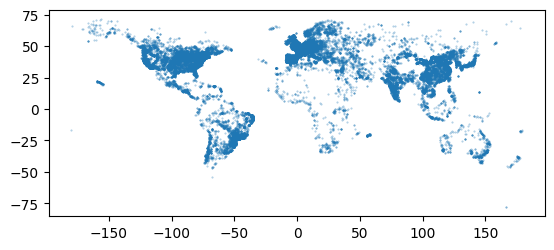

In [4]:
powerplants = gpd.GeoDataFrame(data,
    geometry = gpd.points_from_xy(data["longitude"], data["latitude"]),crs = 'EPSG:4326')
powerplants = powerplants[powerplants.geometry.apply(
    lambda g: g is not None and -180 <= g.x <= 180 and -90 <= g.y <= 90
)]
powerplants.plot(markersize=0.2, alpha=0.4)

In [5]:
powerplants.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,geometry
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.3220,65.1190,Hydro,,,...,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (65.119 32.322)
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.6700,65.7950,Solar,,,...,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (65.795 31.67)
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.6230,65.7920,Solar,,,...,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,POINT (65.792 31.623)
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.5560,69.4787,Hydro,,,...,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (69.4787 34.556)
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,,,...,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,POINT (69.717 34.641)


In [18]:
powerplants.primary_fuel.value_counts()

primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal       10
Name: count, dtype: int64

<Axes: >

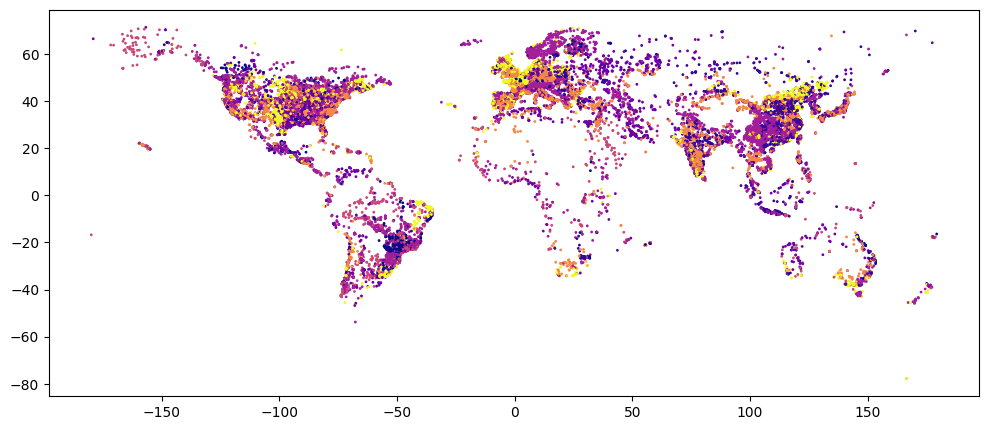

In [23]:
powerplants.plot(cmap="plasma", column="primary_fuel", markersize=1, figsize=(12, 6))

In [65]:
print(data[["longitude", "latitude"]].describe())

       longitude latitude
count      34936    34936
unique     33036    31779
top     121.3570  -2.5213
freq          14       14


In [5]:
# Convert to numeric, bad strings become NaN
data["longitude"] = pd.to_numeric(data["longitude"], errors="coerce")
data["latitude"] = pd.to_numeric(data["latitude"], errors="coerce")

# Show all bad rows
bad = data[
    data["longitude"].isna() | data["latitude"].isna() |
    (data["longitude"] > 180) | (data["longitude"] < -180) |
    (data["latitude"] > 90) | (data["latitude"] < -90)
]

print(f"Bad rows: {len(bad)}")
print(bad[["longitude", "latitude", "country", "primary_fuel"]])

Bad rows: 0
Empty DataFrame
Columns: [longitude, latitude, country, primary_fuel]
Index: []


<Axes: >

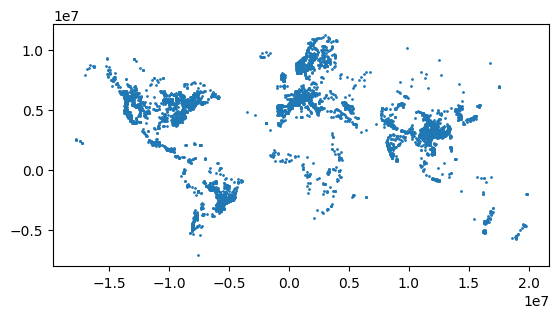

In [74]:
points.plot(markersize=1)

<Axes: xlabel='None', ylabel='None'>

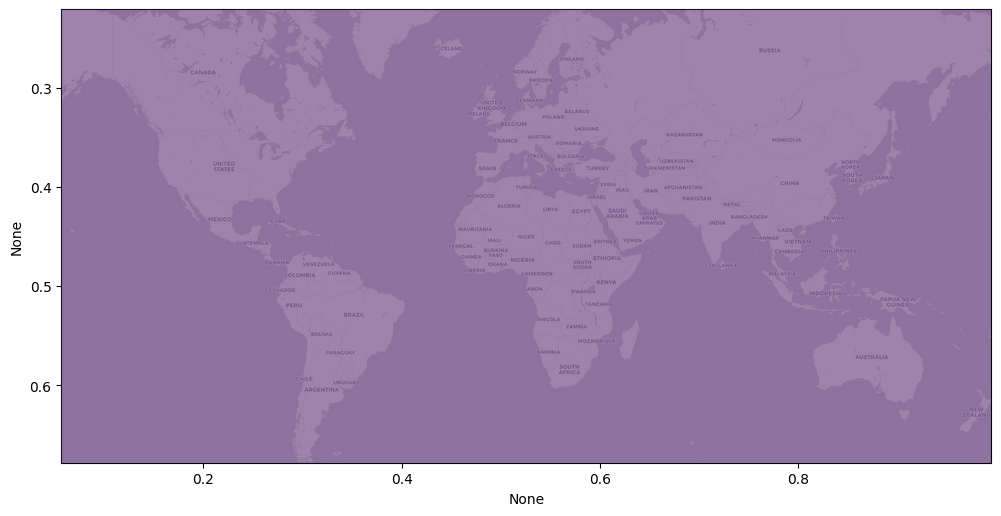

In [6]:
# 1. Filter bad coordinates while still in 4326
points = powerplants[["geometry", "country", "primary_fuel"]]

points = points[
    (points.geometry.x >= -180) & (points.geometry.x <= 180) &
    (points.geometry.y >= -90) & (points.geometry.y <= 90)
]

# 2. Filter fuel type before reprojecting
points = points[points["primary_fuel"] == "Hydro"]

# 3. extent_from_frame needs 4326
extent = tilemapbase.extent_from_frame(points, buffer=0)
# 4. NOW reproject for the KDE plot
points = points.to_crs("EPSG:3857")

# 5. Plot
fig, ax = plt.subplots(figsize=(12, 6))
tilemapbase.init(create=True)
plotter = tilemapbase.Plotter(extent, tilemapbase.tiles.Carto_Light, width=1000)
plotter.plot(ax, allow_large=True)

sns.kdeplot(
    x=points.geometry.x,
    y=points.geometry.y,
    fill=True,
    alpha=0.5,
    cmap="viridis",
    zorder=3,
    ax=ax
)

In [7]:
def plot_kde(all_points, fuel_type, ax, cmap):
    points = all_points[all_points["primary_fuel"] == fuel_type]
    sns.kdeplot(
    x=points.geometry.x,
    y=points.geometry.y,
    fill=True,
    alpha=0.2,
    cmap=cmap,
     thresh=0.3,
    zorder=3,
        ax=ax
)


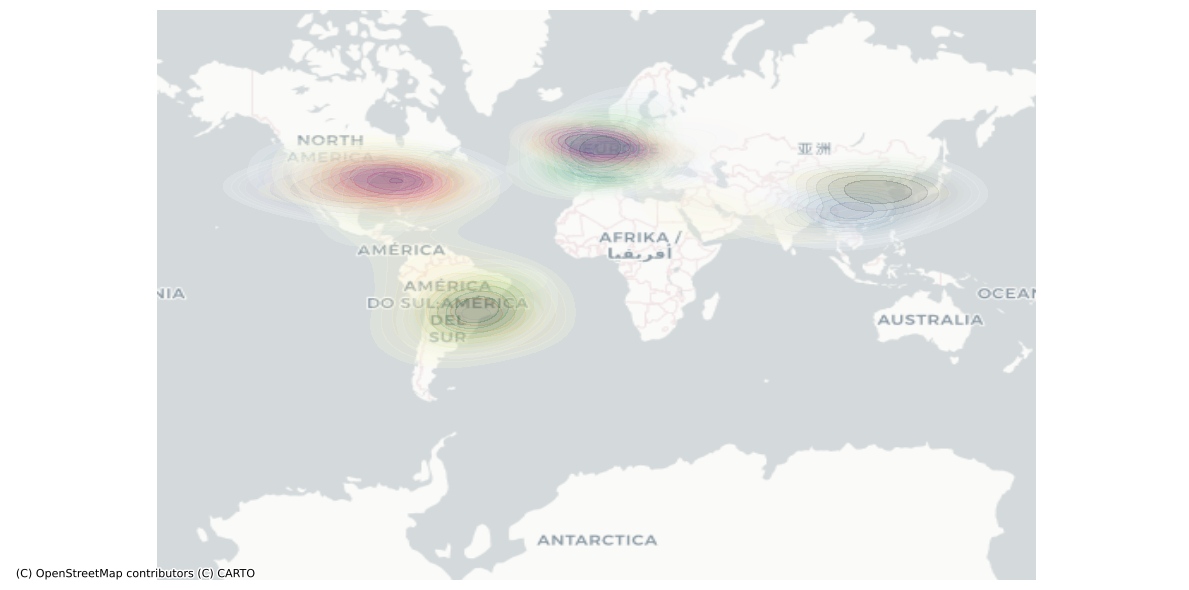

In [8]:


points = powerplants[["geometry", "country", "primary_fuel"]]
points = points.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(12, 6))

fuel_cmaps = {
    "Solar":   "YlOrRd",      # yellow → orange → red, heat/sun
    "Hydro":   "Blues",       # light → deep blue, water
    "Wind":    "GnBu",        # green → blue, sky/air
    "Gas":     "Purples",     # neutral purple, processed fuel
    "Coal":    "Greys",       # grey → black, coal colour
    "Oil":     "YlOrBr",      # yellow → dark brown, crude oil
    "Biomass": "Greens",      # light → dark green, organic
    "Waste":   "RdPu"        # muted red → purple, industrial waste
}

for fuel in fuel_cmaps:
  plot_kde(points, fuel, ax, fuel_cmaps[fuel])
# Solar             
# Hydro              
# Wind               
# Gas                
# Coal               
# Oil                
# Biomass            
# Waste         

contextily.add_basemap(
    ax,
    source=contextily.providers.CartoDB.Positron,
    crs=points.crs
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

<Axes: >

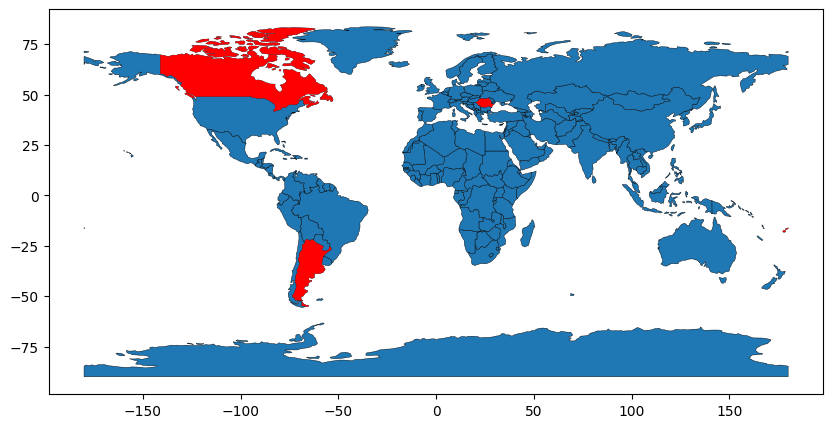

In [6]:
world_proj = gpd.read_file(DATA_DIRECTORY / "ne_110m_admin_0_countries")
countries = ["CAN", "ROU", "FJI", "ARG"]

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

world_proj.plot(edgecolor="black", ax =ax, linewidth=0.3)
world_proj[world_proj["SOV_A3"].isin(countries)].plot(color="red", ax=ax)

In [36]:
plants = powerplants[["country", "primary_fuel", "capacity_mw", "country_long"]]
plants["capacity_mw"] = pd.to_numeric(plants["capacity_mw"], errors="coerce")
countries = world_proj[["SOV_A3", "geometry"]]
plants.head()


,country,primary_fuel,capacity_mw,country_long
0,AFG,Hydro,33.0,Afghanistan
1,AFG,Solar,10.0,Afghanistan
2,AFG,Solar,10.0,Afghanistan
3,AFG,Hydro,66.0,Afghanistan
4,AFG,Hydro,100.0,Afghanistan


In [37]:
# Step 1: total capacity per country + fuel type
fuel_capacity = (
    plants.groupby(["country", "primary_fuel"])["capacity_mw"]
    .sum()
    .reset_index()
)

# Step 2: keep only the fuel with max capacity per country
dominant_fuel = (
    fuel_capacity.loc[
        fuel_capacity.groupby("country")["capacity_mw"].idxmax()
    ]
    .set_index("country")["primary_fuel"]
)

# Step 3: map onto countries, None if no data
countries["dominant_fuel"] = countries["SOV_A3"].map(dominant_fuel)

countries.head()

,SOV_A3,geometry,dominant_fuel
0,FJI,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Hydro
1,TZA,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",Hydro
2,SAH,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN
3,CAN,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",Hydro
4,US1,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",NaN


In [9]:
fuel_capacity.head()

,country,primary_fuel,capacity_mw
0,AFG,Gas,42.00
1,AFG,Hydro,238.55
2,AFG,Solar,20.00
3,AGO,Gas,163.68
4,AGO,Hydro,770.60


In [ ]:
set(countries["SOV_A3"].unique()) - set(plants["country"].unique()) 

In [ ]:
set(plants["country"].unique())  - set(countries["SOV_A3"].unique()) 

In [38]:
# Map non-standard SOV_A3 codes -> standard ISO A3 codes used in plants
sov_to_iso = {
    'AU1': 'AUS',  # Australia
    'BHS': 'BHS',  # Bahamas (already matches, skip or keep)
    'CH1': 'CHN',  # China
    'CU1': 'CUB',  # Cuba
    'DN1': 'DNK',  # Denmark
    'FI1': 'FIN',  # Finland
    'FR1': 'FRA',  # France
    'GB1': 'GBR',  # United Kingdom
    'IS1': 'ISR',  # Israel
    'KA1': 'KAZ',  # Kazakhstan
    'NL1': 'NLD',  # Netherlands
    'NZ1': 'NZL',  # New Zealand
    'SAH': 'ESH',  # Western Sahara
    'US1': 'USA',  # United States
    # No plant data equivalent for these — leave unmapped:
    # 'BLZ', 'CYN', 'HTI', 'SDS', 'SLB', 'SOL', 'SOM', 'TCD', 'TLS', 'VUT'
}

# Apply mapping: create a lookup key that prefers the mapped code
countries["country_key"] = countries["SOV_A3"].map(sov_to_iso).fillna(countries["SOV_A3"])

# Recompute dominant fuel using the new key
countries["dominant_fuel"] = countries["country_key"].map(dominant_fuel)

In [40]:
plants.primary_fuel.unique()

<StringArray>
[         'Hydro',          'Solar',            'Gas',          'Other',
            'Oil',           'Wind',        'Nuclear',           'Coal',
          'Waste',        'Biomass', 'Wave and Tidal',        'Petcoke',
     'Geothermal',        'Storage',   'Cogeneration']
Length: 15, dtype: str

<Axes: >

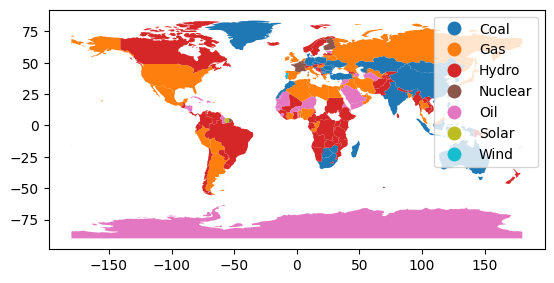

In [41]:
countries.plot(column="dominant_fuel", legend=True)

In [41]:
plants.groupby("country_long")["capacity_mw"].sum().tail()

country_long
Vietnam           41350.490
Western Sahara       23.400
Yemen              1045.000
Zambia             2689.337
Zimbabwe           1670.000
Name: capacity_mw, dtype: float64

In [39]:
plants.groupby("primary_fuel")["capacity_mw"].sum().sort_values(ascending=False)

primary_fuel
Coal              1.965541e+06
Gas               1.493051e+06
Hydro             1.053160e+06
Nuclear           4.079118e+05
Wind              2.630537e+05
Oil               2.618787e+05
Solar             1.883123e+05
Biomass           3.428130e+04
Waste             1.474871e+04
Geothermal        1.268775e+04
Cogeneration      4.048000e+03
Other             3.612860e+03
Petcoke           2.424577e+03
Storage           1.712300e+03
Wave and Tidal    5.522000e+02
Name: capacity_mw, dtype: float64

['Coal', 'Gas', 'Hydro', 'Nuclear', 'Wind', 'Oil', 'Solar', 'Biomass', 'Waste', 'Geothermal', 'Cogeneration', 'Other', 'Petcoke', 'Storage', 'Wave and Tidal']


<Axes: >

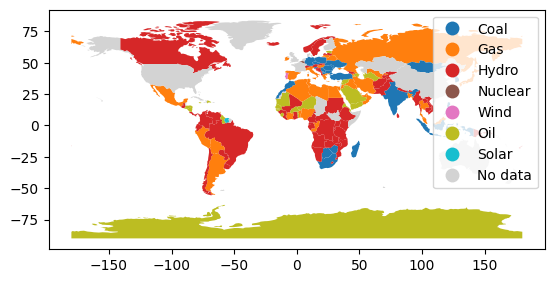

In [15]:
# Order fuel types by total capacity descending
fuel_order = (
    plants.groupby("primary_fuel")["capacity_mw"]
    .sum()
    .sort_values(ascending=False)
    .index.tolist()
)

# Only keep fuel types that are actually dominant in at least one country
dominant_fuels_used = countries["dominant_fuel"].dropna().unique().tolist()
print(fuel_order)
# Filter fuel_order to only those that appear as dominant
fuel_order_filtered = [f for f in fuel_order if f in dominant_fuels_used]

# Replace any values not in the filtered order with NaN first
countries["dominant_fuel"] = countries["dominant_fuel"].where(
    countries["dominant_fuel"].isin(fuel_order_filtered), other=None
)

# Now safe to construct categorical
countries["dominant_fuel"] = pd.Categorical(
    countries["dominant_fuel"],
    categories=fuel_order_filtered,
    ordered=True
)

# Plot — geopandas will respect the categorical order in the legend
countries.plot(
    column="dominant_fuel",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

In [ ]:
countries.dominant_fuel.unique()

['Hydro', 'Oil', 'Gas', 'Coal', NaN, 'Nuclear', 'Solar', 'Wind']
Categories (7, str): ['Coal' < 'Gas' < 'Hydro' < 'Nuclear' < 'Wind' < 'Oil' < 'Solar']

<Axes: >

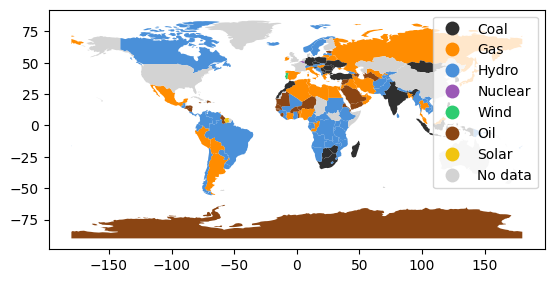

In [21]:
fuel_colors = {
    "Coal":    "#2f2f2f",  # dark grey — coal
    "Gas":     "#ff8c00",  # orange — flame
    "Hydro":   "#4a90d9",  # blue — water
    "Nuclear": "#9b59b6",  # purple — radioactive
    "Wind":    "#2ecc71",  # green — clean/nature
    "Oil":     "#8B4513",  # brown — crude
    "Solar":   "#f1c40f",  # yellow — sun
}

# Build a listed colormap in category order
fuel_order_filtered = ['Coal', 'Gas', 'Hydro', 'Nuclear', 'Wind', 'Oil', 'Solar']
cmap = mcolors.ListedColormap([fuel_colors[f] for f in fuel_order_filtered])

countries.plot(
    column="dominant_fuel",
    cmap=cmap,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
)

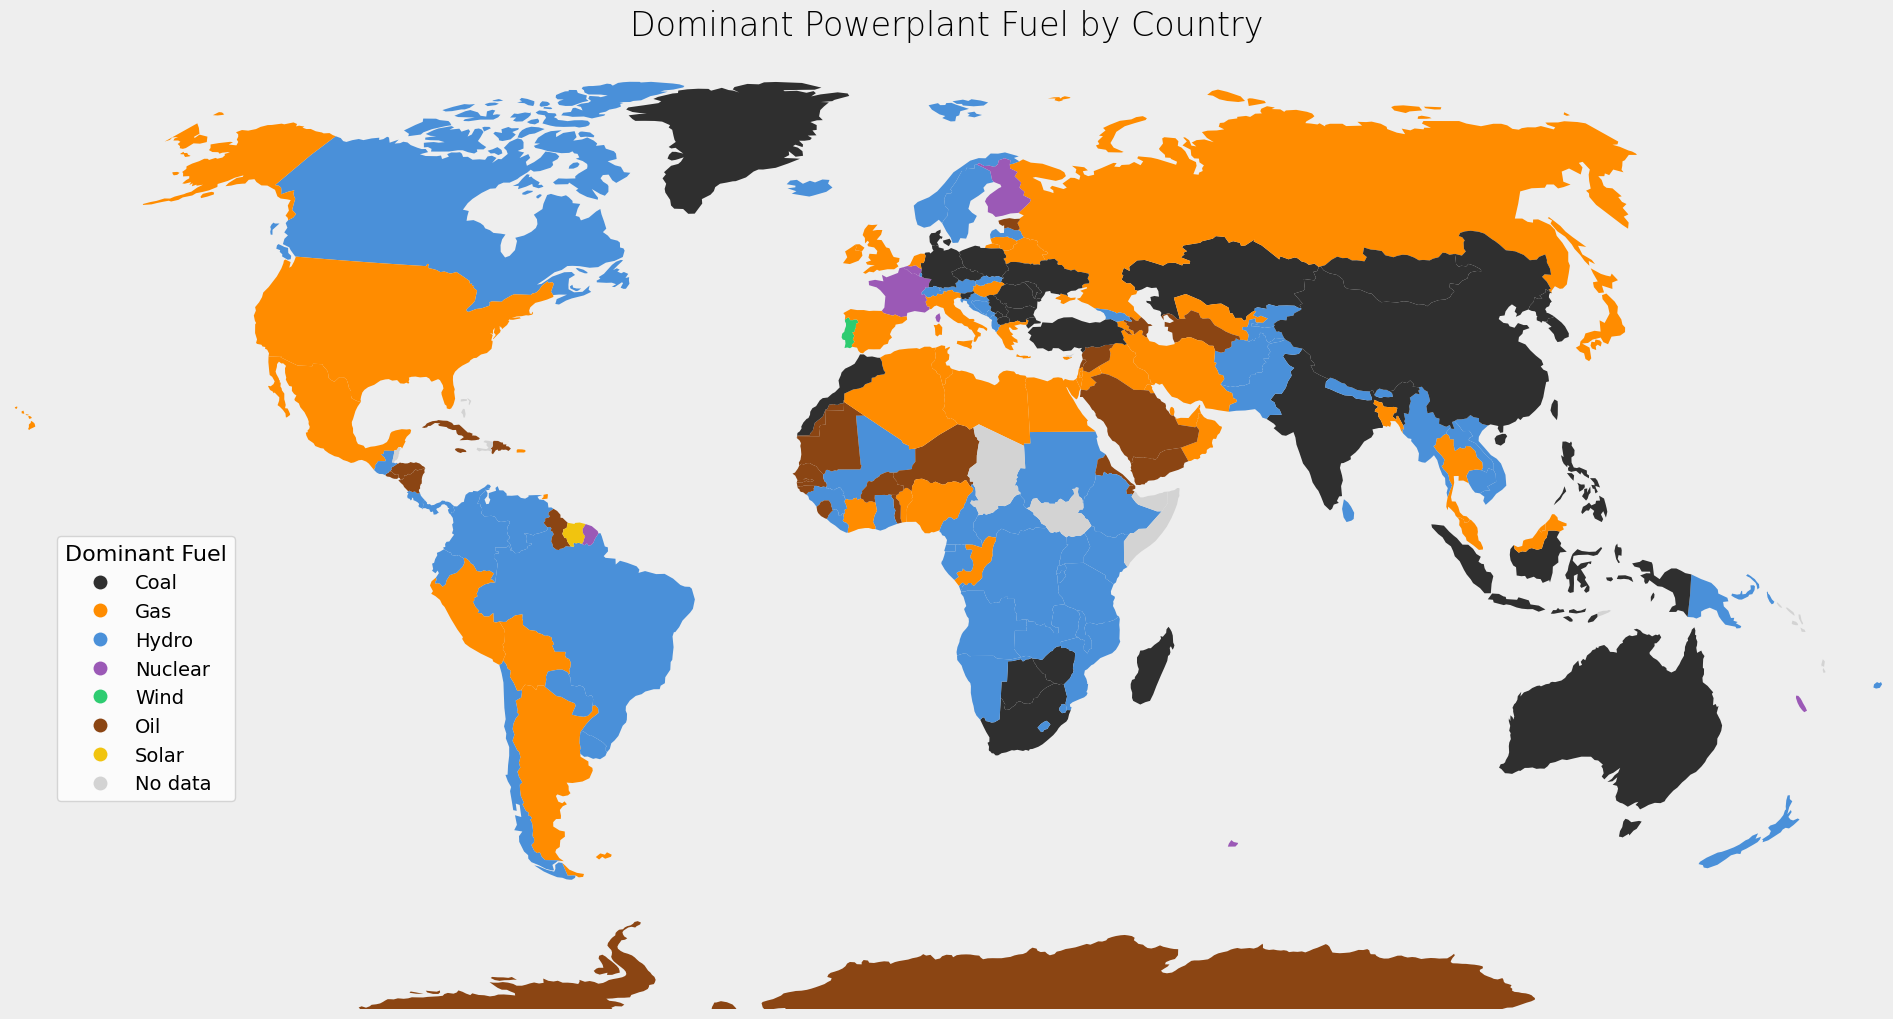

In [ ]:
fuels = countries.to_crs("+proj=wintri")

fig, ax = plt.subplots(figsize=(20, 10))

fuels.plot(
    column="dominant_fuel",
    ax=ax,
    cmap=cmap,
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    legend_kwds={"loc":"upper left", "bbox_to_anchor":(0.02, 0.5), "title": "Dominant Fuel", "title_fontsize": 16, "fontsize": 14,}
)

ax.set_axis_off()
# ax.set_title('Green Space Quality in Espoo\n', fontsize=16)

x1, x2 = ax.get_xlim()
y1, y2 = ax.get_ylim()

# Trim — adjust the fractions to taste
horizontal_trim = (x2 - x1) * 0.01  # 1% hor off each end
vertical_trim = (y2 - y1) * 0.01  # 1% vert off each end
ax.set_xlim(x1 + horizontal_trim * 10, x2 - horizontal_trim * 5)
ax.set_ylim(y1 + vertical_trim * 10, y2 - vertical_trim)

fig.patch.set_facecolor("#EEEEEE") 
plt.title('Dominant Powerplant Fuel by Country', fontdict={'fontsize': '24', 'fontweight': '3'})
plt.tight_layout(pad=0)
# plt.savefig(MAP_DIRECTORY / "map4.png", dpi=300, bbox_inches="tight")
plt.show()


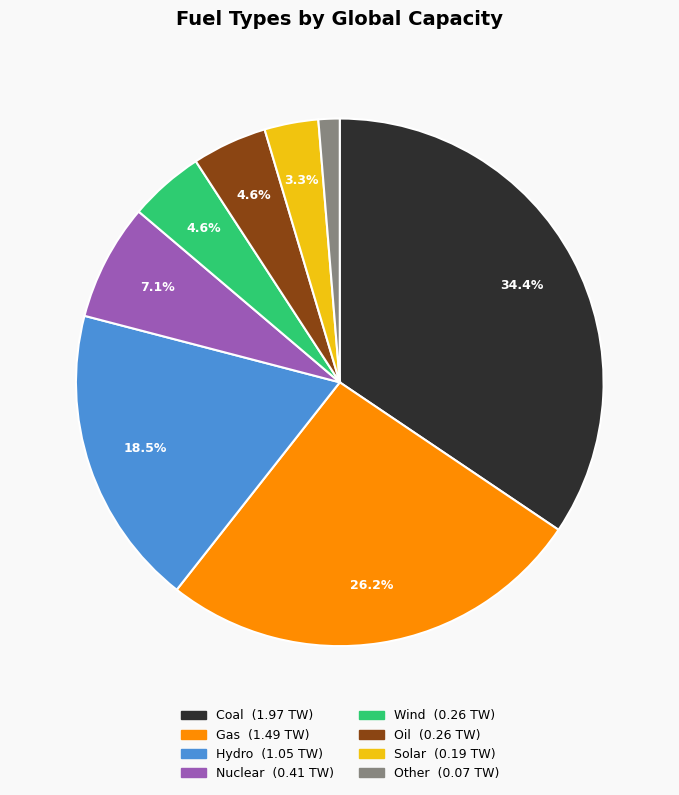

In [66]:
# Fuel Pie Chart

# Aggregate from dataframe
capacity = plants.groupby("primary_fuel")["capacity_mw"].sum().sort_values(ascending=False)

# Split into top 7 (up to Solar) and Other
top_fuels = list(fuel_colors.keys())  # preserves your preferred order
top = capacity[capacity.index.isin(top_fuels)].reindex(top_fuels).dropna()
other = capacity[~capacity.index.isin(top_fuels)].sum()

labels = list(top.index) + ["Other"]
values = list(top.values) + [other]
colors = [fuel_colors[l] for l in top.index] + ["#888780"]
total = sum(values)

fig, ax = plt.subplots(figsize=(8, 8), facecolor="#f9f9f9")
ax.set_facecolor("#f9f9f9")

wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.78,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
)

for t in autotexts:
    t.set_fontsize(9)
    t.set_color("white")
    t.set_fontweight("bold")

legend_labels = [f"{l}  ({v/1e6:.2f} TW)" for l, v in zip(labels, values)]
patches = [Patch(color=colors[i], label=legend_labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.12),
          ncol=2, fontsize=9, frameon=False)

ax.set_title("Fuel Types by Global Capacity", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("fuel_capacity_pie.png", dpi=300, bbox_inches="tight")
plt.show()

['China', 'United States of America', 'India', 'Russia', 'Japan', 'Brazil', 'Canada', 'Other']


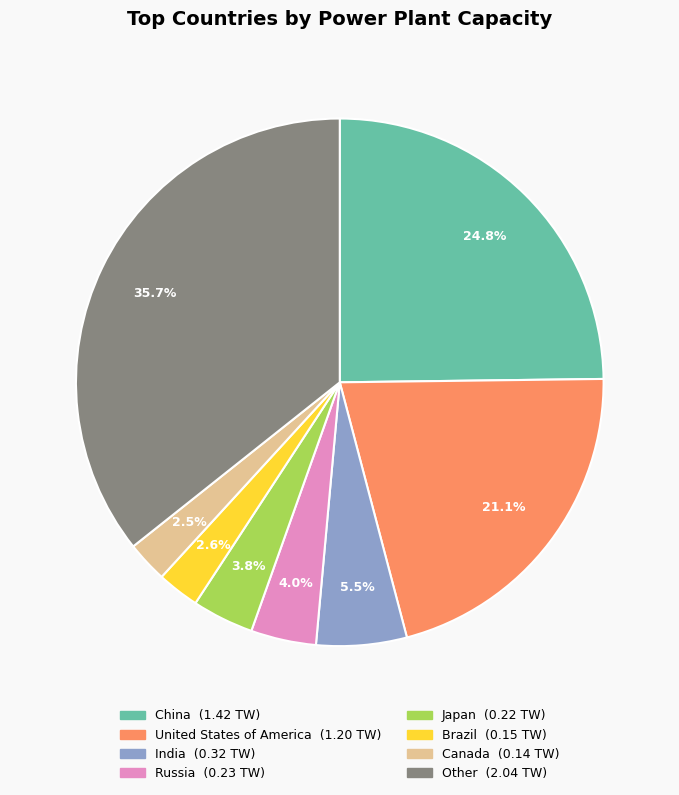

In [65]:
num = 7
country_capacity = plants.groupby("country_long")["capacity_mw"].sum().sort_values(ascending=False)
top_countries = country_capacity.head(num)
other_country = country_capacity.iloc[num:].sum()

country_palette = [
    "#DE2910",  # China — red
    "#3C3B6E",  # USA — navy blue
    "#FF9933",  # India — saffron orange
    "#BC002D",  # Russia — crimson
    "#5AA4E9",  # Russia — blue
    "#009C3B",  # Brazil — green
    "#FF0000",  # Canada — red
][:num]
import matplotlib.cm as cm

# Option 1 — tab10 (default categorical, very clean)
country_palette = [cm.Set2(i) for i in range(num)]


labels = list(top_countries.index) + ["Other"]
values = list(top_countries.values) + [other_country]
colors = country_palette + ["#888780"]
print(labels)
fig, ax = plt.subplots(figsize=(8, 8), facecolor="#f9f9f9")
ax.set_facecolor("#f9f9f9")

wedges, texts, autotexts = ax.pie(
    values,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.78,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
)

for t in autotexts:
    t.set_fontsize(9)
    t.set_color("white")
    t.set_fontweight("bold")

legend_labels = [f"{l}  ({v/1e6:.2f} TW)" for l, v in zip(labels, values)]
patches = [Patch(color=colors[i], label=legend_labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.12),
          ncol=2, fontsize=9, frameon=False)

ax.set_title(f"Top Countries by Power Plant Capacity", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("country_capacity_pie.png", dpi=150, bbox_inches="tight")
plt.show()